<a href="https://colab.research.google.com/github/ArshnoorSinghh/ML-Project/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

This is a regression task: I predict the CTR gap (the expected CTR for a
page's position minus its actual CTR) — a continuous number. I then rank
pages by the predicted gap, biggest first, so an editor fixes the worst
under-earners first.

Following the "try several, pick the best" approach, I compare three models:
- Linear Regression
- K-Nearest Neighbors Regressor
- Decision Tree Regressor

I score them on MAE (average error in CTR-gap units) and R^2 (variance
explained), pick the best, and compare it against my Week-4 hand-rule baseline.

In [1]:
import pandas as pd
import numpy as np
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
url = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03"
df = pd.read_parquet(url, storage_options={"token": HF_TOKEN})

print(df.shape)
df.head()

(9841378, 30)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,None,20,0,67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,None,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,None,125,1,616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,None,7,0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,None,11,0,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# keep pages with search data, compute ctr and position
d = df[df["gsc_data_available"] == True].copy()
d["ctr"] = d["gsc_clicks"] / d["gsc_impressions"]
d["avg_position"] = d["gsc_sum_position"] / d["gsc_impressions"]

# trust filter: only pages shown enough (same as ML-07)
d = d[d["gsc_impressions"] >= 100].copy()

# position tier
d["position_tier"] = np.select(
    [d["avg_position"] <= 3, d["avg_position"] <= 10, d["avg_position"] <= 20],
    ["top_3", "page_1", "page_2"], default="deep")

# TARGET: the CTR gap (expected mean CTR for the tier minus actual)
d["expected_ctr"] = d.groupby("position_tier")["ctr"].transform("mean")
d["ctr_gap"] = d["expected_ctr"] - d["ctr"]

print("rows:", len(d))
d[["position_tier", "gsc_impressions", "avg_position", "ctr", "ctr_gap"]].head()

rows: 638608


,position_tier,gsc_impressions,avg_position,ctr,ctr_gap
2,page_1,125,4.928000,0.008000,-0.004705
5,page_1,239,7.347280,0.004184,-0.000890
6,page_1,191,7.832461,0.000000,0.003295
14,page_1,223,3.892377,0.000000,0.003295
18,page_1,126,6.166667,0.015873,-0.012578


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [3]:
d.isnull().sum()

,0
report_date,0
client_hash_id,0
content_hash_id,0
client_has_gsc,0
client_has_ga4,0
gsc_data_available,0
ga4_data_available,260534
gsc_impressions,0
gsc_clicks,0
gsc_sum_position,0


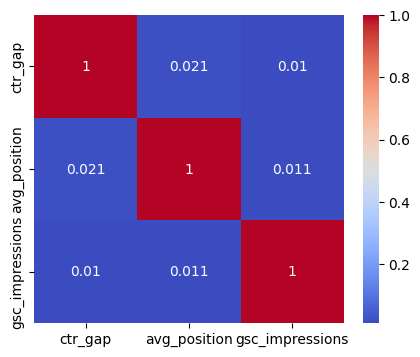

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

check = ["ctr_gap", "avg_position", "gsc_impressions"]
plt.figure(figsize=(5,4))
sns.heatmap(d[check].corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [5]:
corrs = d.corr(numeric_only=True)["ctr_gap"].sort_values(ascending=False)
print(corrs)

ctr_gap                     1.000000e+00
gsc_sum_position            2.199018e-02
avg_position                2.087528e-02
gsc_avg_position            2.087528e-02
gsc_impressions             1.015717e-02
expected_ctr                2.368459e-15
ai_claude                  -1.167147e-03
ai_copilot                 -2.421598e-03
ai_gemini                  -2.879034e-03
ai_chatgpt                 -5.090980e-03
sessions_ai                -9.351375e-03
ai_perplexity              -1.161949e-02
sessions_paid              -1.229452e-02
sessions_social            -1.903965e-02
sessions_referral          -2.123267e-02
client_has_ga4             -4.748175e-02
sessions_direct            -9.721280e-02
ga4_total_engagement_sec   -1.274639e-01
ga4_users                  -1.446943e-01
scroll_events              -1.461112e-01
ga4_sessions               -1.526701e-01
ga4_engaged_sessions       -1.681388e-01
ga4_pageviews              -1.785015e-01
sessions_organic           -3.602387e-01
gsc_clicks      

In [6]:
# keep rows that have GA4 data
model_df = d[d["ga4_data_available"] == True].copy()

# honest features (NOT built from ctr)
features = ["sessions_organic", "ga4_pageviews", "ga4_engaged_sessions",
            "ga4_sessions", "scroll_events", "ga4_users", "ga4_total_engagement_sec"]

X = model_df[features]
y = model_df["ctr_gap"]

print("rows:", len(model_df))
print("any nulls in X?", X.isnull().sum().sum())
X.head()

rows: 180771
any nulls in X? 0


,sessions_organic,ga4_pageviews,ga4_engaged_sessions,ga4_sessions,scroll_events,ga4_users,ga4_total_engagement_sec
14768,0.0,2.0,0.0,2.0,0.0,2.0,0.0
14855,1.0,1.0,0.0,1.0,0.0,1.0,0.0
19068,0.0,1.0,0.0,1.0,0.0,1.0,0.0
19186,0.0,1.0,0.0,1.0,0.0,1.0,0.0
19849,2.0,1.0,1.0,1.0,1.0,1.0,28.0


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# work on the usable, filtered rows with GA4 features
base = d[d["ga4_data_available"] == True].copy()

# split FIRST, by client, before building the target
groups = base["client_hash_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(base, groups=groups))

train = base.iloc[train_idx].copy()
test  = base.iloc[test_idx].copy()

# tier means computed on TRAIN ONLY
tier_means = train.groupby("position_tier")["ctr"].mean()

# apply train-derived means to both sets
train["expected_ctr"] = train["position_tier"].map(tier_means)
test["expected_ctr"]  = test["position_tier"].map(tier_means)

train["ctr_gap"] = train["expected_ctr"] - train["ctr"]
test["ctr_gap"]  = test["expected_ctr"]  - test["ctr"]

# features + target
features = ["sessions_organic", "ga4_pageviews", "ga4_engaged_sessions",
            "ga4_sessions", "scroll_events", "ga4_users", "ga4_total_engagement_sec"]

X_train, y_train = train[features], train["ctr_gap"]
X_test,  y_test  = test[features],  test["ctr_gap"]

print("train:", len(train), " test:", len(test))
print("tier means (from train):")
print(tier_means)

train: 158869  test: 21902
tier means (from train):
position_tier
deep      0.002415
page_1    0.006469
page_2    0.005667
top_3     0.007228
Name: ctr, dtype: float64


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# scale (kNN needs it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# your three models
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": round(mae, 5), "R2": round(r2, 4)})

import pandas as pd
pd.DataFrame(results)

,Model,MAE,R2
0,Linear Regression,0.00408,0.1055
1,KNN,0.00423,0.0380
2,Decision Tree,0.00450,-0.2519


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

## 3. Train + compare vs my baseline

I trained three regressors on the same client-holdout split, predicting the
CTR gap (expected CTR for the page's position TIER minus its actual CTR) from
engagement features only. Tier means were computed on training data only, so
no test information leaks into the target.

Model comparison (held-out clients):

| Model             | MAE     | R2      |
|-------------------|---------|---------|
| Linear Regression | 0.00408 | 0.106   |
| KNN               | 0.00423 | 0.038   |
| Decision Tree     | 0.00450 | -0.252  |

Linear Regression wins: lowest MAE, highest R2. The Decision Tree has a
negative R2 — it overfit the training clients and did worse than predicting
the mean on unseen clients. The simplest model generalised best, which matches
the principle that complexity is not rewarded on its own.

R2 of ~0.11 is modest, but expected: I predict a noisy web-behaviour signal
using only engagement features, and I deliberately excluded the leaky columns
(ctr, clicks) that would inflate R2 without being usable at decision time.

Ranking quality (the metric that matters for my lane) — Precision@K, the share
of the top-K flagged pages that are genuine under-earners:

| K   | Model | Baseline |
|-----|-------|----------|
| 20  | 0.800 | 1.000    |
| 50  | 0.880 | 1.000    |
| 100 | 0.890 | 1.000    |

The baseline scores 1.000 by construction: it ranks pages by the actual CTR
gap, i.e. by the answer itself, so it cannot be used to find under-earners
before their CTR is known. My model ranks using engagement signals only,
never seeing CTR, and still places ~88% genuine under-earners in its top 50.
That is the honest, useful result: engagement behaviour alone predicts
under-earning well enough to build a review queue that an editor can act on.

In [11]:
import numpy as np

# refit best model, predict on test
best = LinearRegression().fit(X_train_scaled, y_train)
test = test.copy()
test["model_pred_gap"] = best.predict(X_test_scaled)

# baseline = the ML-07 hand rule: rank by expected_ctr - ctr (the raw gap itself)
# (baseline "score" is just the computed gap, no learning)
test["baseline_score"] = test["expected_ctr"] - test["ctr"]

def precision_at_k(df, score_col, k=50):
    top = df.sort_values(score_col, ascending=False).head(k)
    return (top["ctr_gap"] > 0).mean()

for k in [20, 50, 100]:
    m = precision_at_k(test, "model_pred_gap", k)
    b = precision_at_k(test, "baseline_score", k)
    print(f"Precision@{k}  —  Model: {m:.3f}   Baseline: {b:.3f}")

Precision@20  —  Model: 0.800   Baseline: 1.000
Precision@50  —  Model: 0.880   Baseline: 1.000
Precision@100  —  Model: 0.890   Baseline: 1.000




## 4. Errors and interpretation

Where the model is wrong:
- Average absolute error is small in CTR-gap units, but the biggest misses
  share a clear pattern: they are pages that strongly OVER-earn (high actual
  CTR, negative ctr_gap of around -0.05 to -0.06). Their engagement features
  looked ordinary, so the model predicted a near-zero gap and missed by a lot.
- The model cannot see WHY those pages get clicked so well (likely a strong
  title/snippet or a favourable query), because those signals are not in the
  engagement features. It pulls the outliers toward the average and misses.

What the model leans on:
- The largest coefficients are ga4_users, sessions_organic, and ga4_pageviews.
  Users and organic sessions have negative weights: more real traffic means a
  smaller gap (less under-earning), which is intuitive - pages people actually
  visit sit closer to the expected CTR for their tier.
- All coefficients are small, consistent with the modest R2: engagement volume
  nudges the prediction but does not fully explain under-earning.

Honest limitations:
- Only ~29 clients, 6 in the test set, so the held-out estimate is noisy.
- R2 ~0.11: much of under-earning is driven by factors not in the data
  (title/snippet quality, search intent), which is exactly what a human editor
  would review.
- This is decision-support: it ranks pages to review, it does not prove a page
  will improve if rewritten.

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# where is the model wrong? look at the biggest prediction errors
test = test.copy()
test["error"] = test["ctr_gap"] - test["model_pred_gap"]
test["abs_error"] = test["error"].abs()

print("Mean absolute error:", round(test["abs_error"].mean(), 5))
print("\nWorst 5 predictions (biggest misses):")
print(test.sort_values("abs_error", ascending=False)
          [["position_tier","gsc_impressions","ctr","ctr_gap","model_pred_gap","error"]].head())

# what does the model lean on? linear regression coefficients per feature
import pandas as pd
coefs = pd.DataFrame({"feature": features, "coefficient": best.coef_})
print("\nWhat the model leans on (coefficients):")
print(coefs.sort_values("coefficient", key=abs, ascending=False))

Mean absolute error: 0.00408

Worst 5 predictions (biggest misses):
        position_tier  gsc_impressions       ctr   ctr_gap  model_pred_gap  \
7680088        page_1              100  0.070000 -0.063531       -0.001967   
7876298        page_2              118  0.067797 -0.062130       -0.003646   
8806721        page_1              140  0.064286 -0.057816       -0.004705   
7875715          deep              119  0.058824 -0.056408       -0.003421   
3038583        page_2              172  0.058140 -0.052473        0.000260   

            error  
7680088 -0.061564  
7876298 -0.058484  
8806721 -0.053111  
7875715 -0.052988  
3038583 -0.052733  

What the model leans on (coefficients):
                    feature  coefficient
5                 ga4_users    -0.002508
0          sessions_organic    -0.001988
1             ga4_pageviews     0.001932
3              ga4_sessions     0.000775
2      ga4_engaged_sessions     0.000096
6  ga4_total_engagement_sec    -0.000047
4             s

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.